In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ***Data Exploration***

In [2]:
df = pd.read_csv(r"fifa_eda.csv")
df.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0


In [3]:
df.shape

(18207, 18)

In [4]:
df.isna().sum()

ID                            0
Name                          0
Age                           0
Nationality                   0
Overall                       0
Potential                     0
Club                        241
Value                       252
Wage                          0
Preferred Foot                0
International Reputation     48
Skill Moves                  48
Position                      0
Joined                        0
Contract Valid Until        289
Height                        0
Weight                        0
Release Clause                0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        18207 non-null  int64  
 1   Name                      18207 non-null  object 
 2   Age                       18207 non-null  int64  
 3   Nationality               18207 non-null  object 
 4   Overall                   18207 non-null  int64  
 5   Potential                 18207 non-null  int64  
 6   Club                      17966 non-null  object 
 7   Value                     17955 non-null  float64
 8   Wage                      18207 non-null  float64
 9   Preferred Foot            18207 non-null  object 
 10  International Reputation  18159 non-null  float64
 11  Skill Moves               18159 non-null  float64
 12  Position                  18207 non-null  object 
 13  Joined                    18207 non-null  int64  
 14  Contra

In [6]:
df.describe()

,ID,Age,Overall,Potential,Value,Wage,International Reputation,Skill Moves,Joined,Height,Weight,Release Clause
count,18207.000000,18207.000000,18207.000000,18207.000000,17955.000000,18207.000000,18159.000000,18159.000000,18207.000000,18207.000000,18207.000000,18207.000000
mean,214298.338606,25.122206,66.238699,71.307299,2444.530214,9.731312,1.113222,2.361308,2016.420607,5.946771,165.979129,4585.060971
std,29965.244204,4.669943,6.908930,6.136496,5626.715434,21.999290,0.394031,0.756164,2.018194,0.220514,15.572775,10630.414430
min,16.000000,16.000000,46.000000,48.000000,10.000000,0.000000,1.000000,1.000000,1991.000000,5.083333,110.000000,13.000000
25%,200315.500000,21.000000,62.000000,67.000000,325.000000,1.000000,1.000000,2.000000,2016.000000,5.750000,154.000000,570.000000
50%,221759.000000,25.000000,66.000000,71.000000,700.000000,3.000000,1.000000,2.000000,2017.000000,5.916667,165.000000,1300.000000
75%,236529.500000,28.000000,71.000000,75.000000,2100.000000,9.000000,1.000000,3.000000,2018.000000,6.083333,176.000000,4585.060806
max,246620.000000,45.000000,94.000000,95.000000,118500.000000,565.000000,5.000000,5.000000,2018.000000,6.750000,243.000000,228100.000000


In [7]:
df.describe(include="O")

,Name,Nationality,Club,Preferred Foot,Position,Contract Valid Until
count,18207,18207,17966,18207,18207,17918
unique,17194,164,651,2,27,35
top,J. Rodríguez,England,RC Celta,Right,ST,2019-01-01
freq,11,1662,33,13996,2154,4870


In [8]:
df.dtypes

ID                            int64
Name                         object
Age                           int64
Nationality                  object
Overall                       int64
Potential                     int64
Club                         object
Value                       float64
Wage                        float64
Preferred Foot               object
International Reputation    float64
Skill Moves                 float64
Position                     object
Joined                        int64
Contract Valid Until         object
Height                      float64
Weight                      float64
Release Clause              float64
dtype: object

In [9]:
df.tail()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
18202,238813,J. Lundstram,19,England,47,65,Crewe Alexandra,60.0,1.0,Right,1.0,2.0,CM,2017,2019-01-01,5.750000,134.0,143.0
18203,243165,N. Christoffersson,19,Sweden,47,63,Trelleborgs FF,60.0,1.0,Right,1.0,2.0,ST,2018,2020-01-01,6.250000,170.0,113.0
18204,241638,B. Worman,16,England,47,67,Cambridge United,60.0,1.0,Right,1.0,2.0,ST,2017,2021-01-01,5.666667,148.0,165.0
18205,246268,D. Walker-Rice,17,England,47,66,Tranmere Rovers,60.0,1.0,Right,1.0,2.0,RW,2018,2019-01-01,5.833333,154.0,143.0
18206,246269,G. Nugent,16,England,46,66,Tranmere Rovers,60.0,1.0,Right,1.0,2.0,CM,2018,2019-01-01,5.833333,176.0,165.0


# ***Data Cleaning***

In [10]:
df.isna().sum()

ID                            0
Name                          0
Age                           0
Nationality                   0
Overall                       0
Potential                     0
Club                        241
Value                       252
Wage                          0
Preferred Foot                0
International Reputation     48
Skill Moves                  48
Position                      0
Joined                        0
Contract Valid Until        289
Height                        0
Weight                        0
Release Clause                0
dtype: int64

In [11]:
new_cols = list()
for i in df.columns:
    new_cols.append(i.strip().replace(" ", "_"))
df.columns = new_cols
df.columns

Index(['ID', 'Name', 'Age', 'Nationality', 'Overall', 'Potential', 'Club',
       'Value', 'Wage', 'Preferred_Foot', 'International_Reputation',
       'Skill_Moves', 'Position', 'Joined', 'Contract_Valid_Until', 'Height',
       'Weight', 'Release_Clause'],
      dtype='object')

In [12]:
df = df[~(df["Club"].isna())]

- Dropped all the rows where the club name is empty. Because replacing them with some other club name may rise the inconsistency in the data.

In [13]:
df.loc[df["Value"].isna(), "Value"] = df["Value"].mean()

* Replced the Value column with the Average value of that column in order to avoid nulls.

In [14]:
df["International_Reputation"].unique()

array([ 5.,  4.,  3.,  2.,  1., nan])

In [15]:
df.loc[df["International_Reputation"].isna(), "International_Reputation"] = df["International_Reputation"].mode()[0]

* Fixed the Null values of International_Reputation column with mode value.

In [16]:
df["Skill_Moves"].unique()

array([ 4.,  5.,  1.,  3.,  2., nan])

In [17]:
df.loc[df["Skill_Moves"].isna(), "Skill_Moves"] = df["Skill_Moves"].mode()[0]

* Fixed the Null values of Skill_Moves column with mode value.

In [18]:
df["Contract_Valid_Until"] = pd.to_datetime(df["Contract_Valid_Until"], errors="coerce")
df.loc[df["Contract_Valid_Until"].isna(), "Contract_Valid_Until"] = df["Contract_Valid_Until"].mode()[0]

* Fixed the Null values of Contract_Valid_Until column with mode value.

In [19]:
df.isna().sum()

ID                          0
Name                        0
Age                         0
Nationality                 0
Overall                     0
Potential                   0
Club                        0
Value                       0
Wage                        0
Preferred_Foot              0
International_Reputation    0
Skill_Moves                 0
Position                    0
Joined                      0
Contract_Valid_Until        0
Height                      0
Weight                      0
Release_Clause              0
dtype: int64

In [20]:
df[df.duplicated()]

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred_Foot,International_Reputation,Skill_Moves,Position,Joined,Contract_Valid_Until,Height,Weight,Release_Clause


In [21]:
df.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred_Foot,International_Reputation,Skill_Moves,Position,Joined,Contract_Valid_Until,Height,Weight,Release_Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17966 entries, 0 to 18206
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ID                        17966 non-null  int64         
 1   Name                      17966 non-null  object        
 2   Age                       17966 non-null  int64         
 3   Nationality               17966 non-null  object        
 4   Overall                   17966 non-null  int64         
 5   Potential                 17966 non-null  int64         
 6   Club                      17966 non-null  object        
 7   Value                     17966 non-null  float64       
 8   Wage                      17966 non-null  float64       
 9   Preferred_Foot            17966 non-null  object        
 10  International_Reputation  17966 non-null  float64       
 11  Skill_Moves               17966 non-null  float64       
 12  Position               

# ***Exploratory Data Analysis (EDA)***

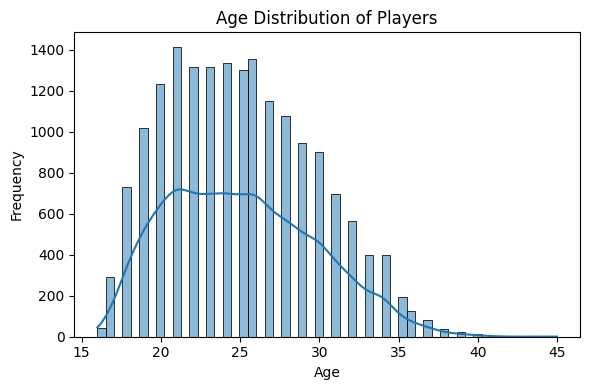

In [23]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="Age", kde=True)
plt.title("Age Distribution of Players")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()

- The majority of players are concentrated in their early-to-mid-twenties.
- The highest frequency falls around the age of 25.
- There's a sharp decline in the number of players after the age of 30, which aligns with the common peak and decline of a professional football player's career.

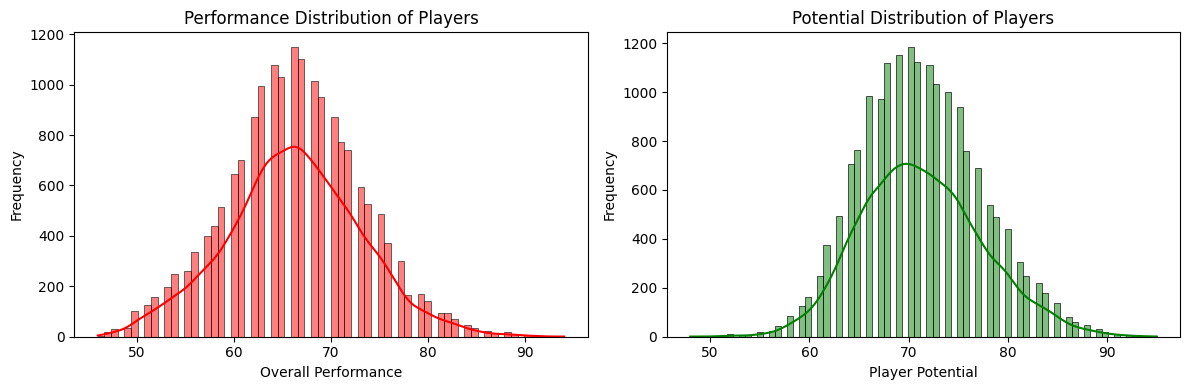

In [34]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x="Overall", kde=True, color="red")
plt.title("Performance Distribution of Players")
plt.xlabel("Overall Performance")
plt.ylabel("Frequency")
plt.tight_layout()
plt.subplot(1, 2, 2)
sns.histplot(data=df, x="Potential", kde=True, color="green")
plt.title("Potential Distribution of Players")
plt.xlabel("Player Potential")
plt.ylabel("Frequency")
plt.tight_layout()

- The most common "Overall" rating is 66, indicating that most players are clustered around an average performance level.
- The mean "Potential" (71.3) is slightly higher than the mean "Overall" (66.2), which is logical as it represents a player's projected future ability.

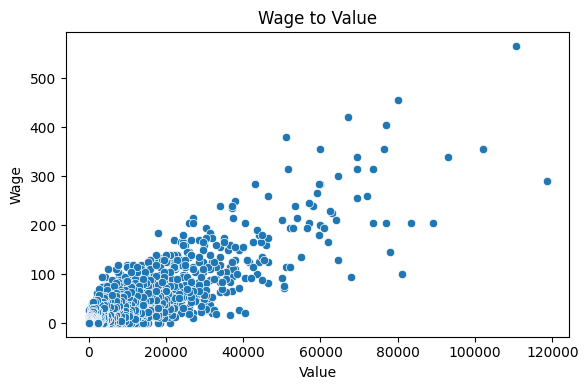

In [108]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="Value", y="Wage")
plt.title("Wage to Value")
plt.xlabel("Value")
plt.ylabel("Wage")
plt.tight_layout()

- Players with higher market values tend to earn higher wages.
- While the relationship is generally linear, there is considerable spread, meaning that for a given value, wages can vary. This could be due to factors like contract length, player age, or club-specific financial power not captured in the data.

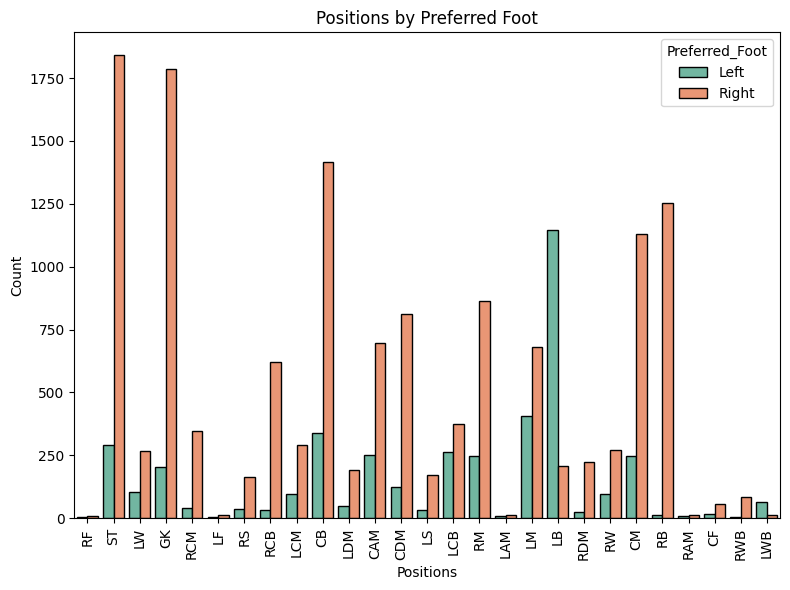

In [111]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="Position", edgecolor="black", hue="Preferred_Foot", palette="Set2")
plt.xticks(rotation=90)
plt.title("Positions by Preferred Foot")
plt.xlabel("Positions")
plt.ylabel("Count")
plt.tight_layout()

- Across all 27 positions, the count of right-footed players is consistently and significantly higher than left-footed players.

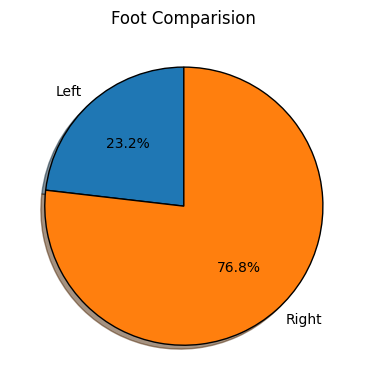

In [112]:
data = df.groupby("Preferred_Foot").count().reset_index().iloc[:, :2].rename(columns={"ID" : "Count"})
plt.figure(figsize=(4, 4))
plt.pie(data["Count"], labels=data["Preferred_Foot"], startangle=90, shadow=True, wedgeprops={"edgecolor" : "black"}, autopct="%1.1f%%")
plt.title("Foot Comparision")
plt.tight_layout()

- There is a strong dominance over left footed players by the right footed players, with 76.8% contribution among all the players.

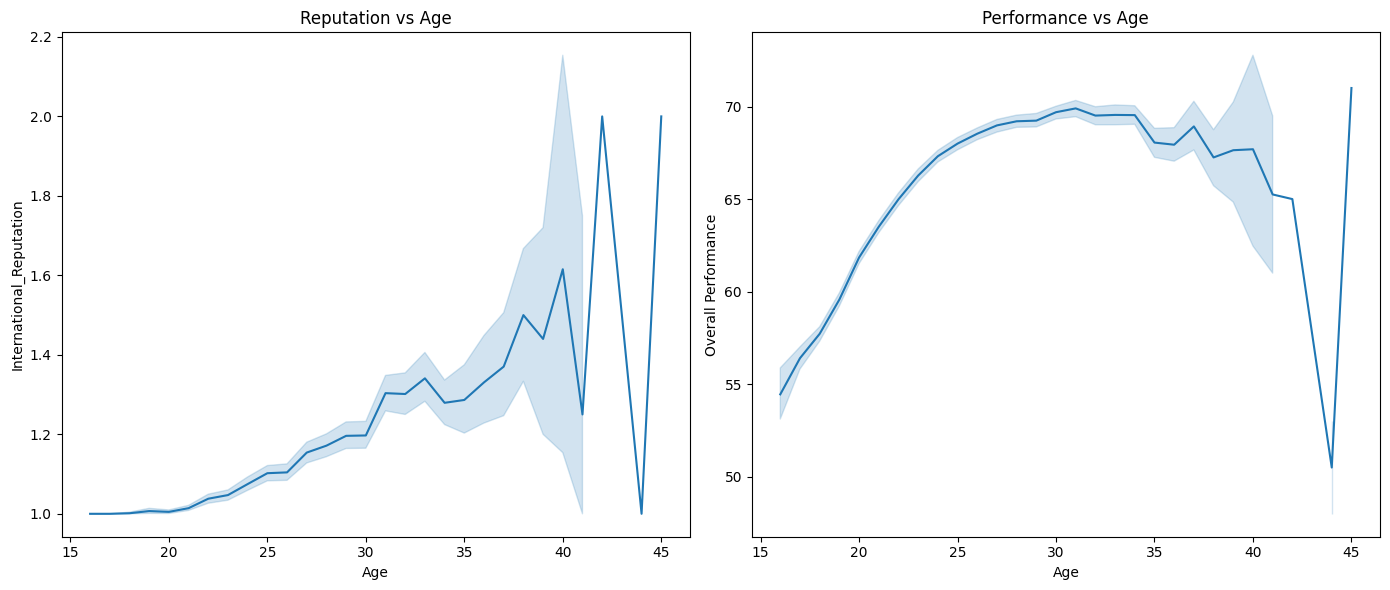

In [72]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x="Age", y="International_Reputation")
plt.title("Reputation vs Age")
plt.tight_layout()
plt.subplot(1, 2, 2)
sns.lineplot(data=df, x="Age", y="Overall")
plt.title("Performance vs Age")
plt.ylabel("Overall Performance")
plt.tight_layout()

- ***Performance vs Age:*** The average "Overall" rating increases steadily from age 16, peaks around age 27-28, and then gradually declines as players move past their physical prime.
- ***Reputation vs Age:*** The "International_Reputation" follows a very similar pattern but peaks slightly later, around age 30. This suggests that a player's fame and recognition can lag slightly behind their on-field performance, often accumulating over a career and peaking just as their performance begins its decline.

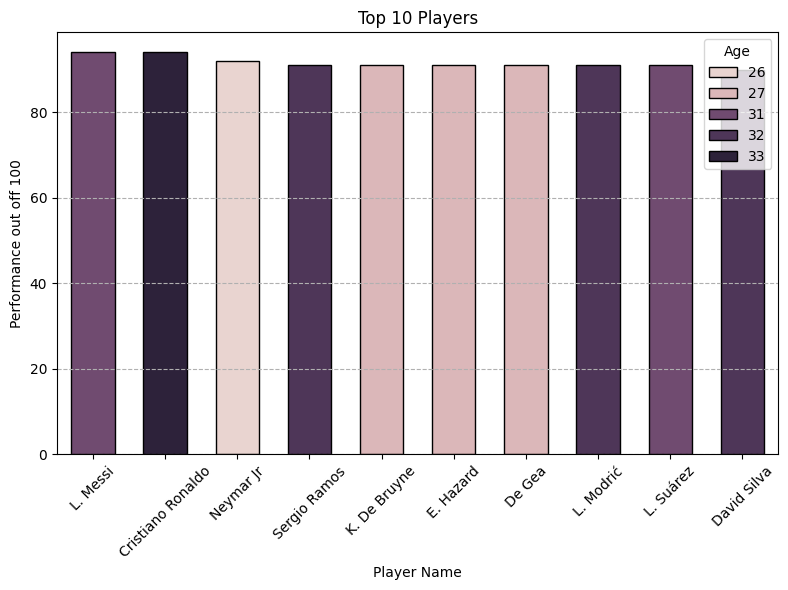

In [110]:
data = df.sort_values(by="Overall", ascending=False)[:10]
plt.figure(figsize=(8, 6))
sns.barplot(data=data, x="Name", y="Overall", edgecolor="black", width=0.6, hue="Age")
plt.title("Top 10 Players")
plt.xlabel("Player Name")
plt.ylabel("Performance out off 100")
plt.xticks(rotation=45)
plt.grid(True, axis="y", ls="--")
plt.tight_layout()

- The top 10 players are all aged 27 or older, with icons like L. Messi (31), Cristiano Ronaldo (33), and Neymar Jr (26) topping the chart. This confirms that peak "Overall" ratings are achieved by players at the height of their careers and reputations.
- The color coding by age shows that the very top of the list is an "older" group, with younger players not yet breaking into the absolute top tier of overall performance.

# ***Conclusion***

This project demonstrates how data analytics can transform a complex dataset into actionable insights about professional football. The patterns uncovered—from the economics of player valuation to the science of career trajectories—provide both immediate understanding and a foundation for deeper investigation. In an industry where multi-million pound decisions hinge on player evaluation, such data-driven insights are invaluable.